In [5]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()

X = digits.data       # shape (1797, 64)
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [6]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Second split: split temp equally into validation and test (20% each total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1078, 64)
Validation shape: (359, 64)
Test shape: (360, 64)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train mean (approx):", X_train_scaled.mean())
print("Train std (approx):", X_train_scaled.std())

Train mean (approx): 4.5315225494904345e-18
Train std (approx): 0.9682458365518551


In [8]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)

print("Number of components:", len(pca_full.explained_variance_))

Number of components: 64


First 10 explained variance ratios:
 [0.1215666  0.0979756  0.08435215 0.06938016 0.04872529 0.0452997
 0.03986067 0.03456291 0.03139634 0.03013433]

Cumulative variance (first 10):
 [0.1215666  0.2195422  0.30389435 0.3732745  0.4219998  0.4672995
 0.50716017 0.54172307 0.57311941 0.60325374]


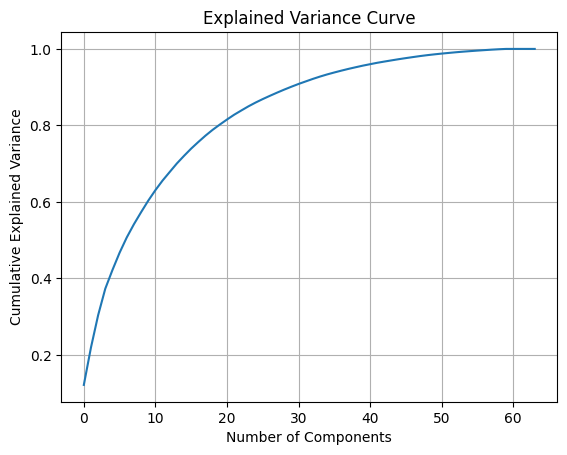

In [9]:
import numpy as np
import matplotlib.pyplot as plt

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("First 10 explained variance ratios:\n", explained_variance[:10])
print("\nCumulative variance (first 10):\n", cumulative_variance[:10])

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Curve")
plt.grid()
plt.show()

In [10]:
pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Train shape after PCA:", X_train_pca.shape)
print("Validation shape after PCA:", X_val_pca.shape)
print("Test shape after PCA:", X_test_pca.shape)

print("Retained variance:", np.sum(pca.explained_variance_ratio_))

Train shape after PCA: (1078, 30)
Validation shape after PCA: (359, 30)
Test shape after PCA: (360, 30)
Retained variance: 0.9011772066710386


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Without PCA
clf_full = LogisticRegression(max_iter=5000)
clf_full.fit(X_train_scaled, y_train)

val_pred_full = clf_full.predict(X_val_scaled)
test_pred_full = clf_full.predict(X_test_scaled)

print("Validation Accuracy (No PCA):", accuracy_score(y_val, val_pred_full))
print("Test Accuracy (No PCA):", accuracy_score(y_test, test_pred_full))

Validation Accuracy (No PCA): 0.9665738161559888
Test Accuracy (No PCA): 0.9638888888888889


In [13]:
from sklearn.metrics import accuracy_score

clf_pca = LogisticRegression(max_iter=5000)
clf_pca.fit(X_train_pca, y_train)

val_pred_pca = clf_pca.predict(X_val_pca)
test_pred_pca = clf_pca.predict(X_test_pca)

print("Validation Accuracy (With PCA):", accuracy_score(y_val, val_pred_pca))
print("Test Accuracy (With PCA):", accuracy_score(y_test, test_pred_pca))

Validation Accuracy (With PCA): 0.9442896935933147
Test Accuracy (With PCA): 0.9527777777777777


In [14]:
pca95 = PCA(n_components=0.95)

X_train_pca95 = pca95.fit_transform(X_train_scaled)
X_val_pca95 = pca95.transform(X_val_scaled)
X_test_pca95 = pca95.transform(X_test_scaled)

print("Number of components retained:", pca95.n_components_)
print("Retained variance:", np.sum(pca95.explained_variance_ratio_))

Number of components retained: 39
Retained variance: 0.9521876373662059


In [15]:
clf_pca95 = LogisticRegression(max_iter=5000)
clf_pca95.fit(X_train_pca95, y_train)

val_pred_pca95 = clf_pca95.predict(X_val_pca95)
test_pred_pca95 = clf_pca95.predict(X_test_pca95)

print("Validation Accuracy (95% PCA):", accuracy_score(y_val, val_pred_pca95))
print("Test Accuracy (95% PCA):", accuracy_score(y_test, test_pred_pca95))

Validation Accuracy (95% PCA): 0.9526462395543176
Test Accuracy (95% PCA): 0.9666666666666667
